## 1.Import Required libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt

## 2.Data Collection

In [2]:
claimants = pd.read_csv("claimants.csv")
claimants

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3.Data Understanding

In [4]:
claimants.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,3.806307
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,10.636903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,0.400000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.069500
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,3.781500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


In [5]:
claimants.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [6]:
claimants.shape

(1340, 7)

In [8]:
claimants.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4.Data Preparation

### 4.1. Data Cleaning

In [3]:
claimants.dropna(inplace=True)

In [10]:
claimants.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [11]:
claimants.shape

(1096, 7)

### 4.2. Separate Inputs and outputs

In [4]:
X = claimants.drop(labels=["CASENUM","ATTORNEY"],axis=1)
X.head()

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038


In [5]:
y= claimants["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5.Model building

### 5.1 Model Validation Technique - train Test Split

In [68]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=34,shuffle=True)

In [18]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
478,0.0,1.0,1.0,10.0,1.318
387,1.0,1.0,0.0,55.0,0.604
47,0.0,1.0,0.0,1.0,0.000
220,1.0,1.0,1.0,7.0,0.983
152,1.0,1.0,0.0,6.0,0.075
...,...,...,...,...,...
731,0.0,1.0,0.0,30.0,4.014
817,0.0,1.0,0.0,48.0,0.390
557,0.0,1.0,0.0,30.0,0.565
386,1.0,1.0,0.0,35.0,0.860


In [19]:
X_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
627,1.0,1.0,0.0,40.0,6.337
1125,1.0,1.0,0.0,37.0,4.609
1124,1.0,1.0,0.0,46.0,0.730
1025,1.0,1.0,0.0,38.0,3.406
481,1.0,1.0,0.0,70.0,0.566
...,...,...,...,...,...
658,0.0,1.0,0.0,14.0,4.479
1257,0.0,1.0,0.0,7.0,0.453
1015,1.0,0.0,0.0,69.0,3.110
1114,1.0,1.0,0.0,0.0,7.169


### 5.2. KFold CV

In [14]:
from sklearn.model_selection import KFold,cross_val_score

kfold = KFold(n_splits=5,shuffle=True,random_state=34)

cv_scores = cross_val_score(estimator=logistic_model,X=X,y=y,cv=kfold)
print(cv_scores)
print("CV SCore:",cv_scores.mean().round(2))
print(cv_scores.std().round(2))

[0.68181818 0.7260274  0.74429224 0.69863014 0.6803653 ]
CV SCore: 0.71
0.03


## 6.Model Training

In [8]:
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,VotingClassifier

In [9]:
logistic_model=LogisticRegression()

In [93]:
rf_classfier = RandomForestClassifier(n_estimators=100,max_depth=5,criterion='entropy')
rf_classfier.fit(X_train,y_train)

,n_estimators,100
,criterion,'entropy'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
ada_boost_classifier = AdaBoostClassifier()
ada_boost_classifier.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [94]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [27]:
dt_model = DecisionTreeClassifier(criterion="entropy",max_depth=5)

In [28]:
dt_model

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Stacking Technique

In [ ]:
logistic_classifier = Logistic_Regression()
dt_classifier= DecisionTreeClassifier()


VotingClassifier(estimators=[("logistic_model",logistic_classifier),
                            (""dt_model",dt_classifier)])

### GridSearch CV (Cross validation)

In [92]:
from sklearn.model_selection import GridSearchCV

grid_search=GridSearchCV(estimator = rf_classfier,param_grid= {"max_depth":[5,6,7,8,9,10],
                                                "criterion":['gini','entropy'],
                                                          "n_estimators":[50,75,100,150]})

grid_search.fit(X,y)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 100}
0.7335533416355334


In [37]:
from sklearn.model_selection import GridSearchCV

GridSearchCV(estimator=dt_model,param_grid={"max_depth":[5,6,7,8,9,10],
                                            "criterion":['gini','entropy']})

grid_search.fit(X_train,y_train)

print(grid_search.best_estimator_)
print(grid_search.best_score_)
print(grid_search.best_params_)

DecisionTreeClassifier(criterion='entropy', max_depth=5)
0.7157532467532468
{'criterion': 'entropy', 'max_depth': 5}


In [38]:
dt_model.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


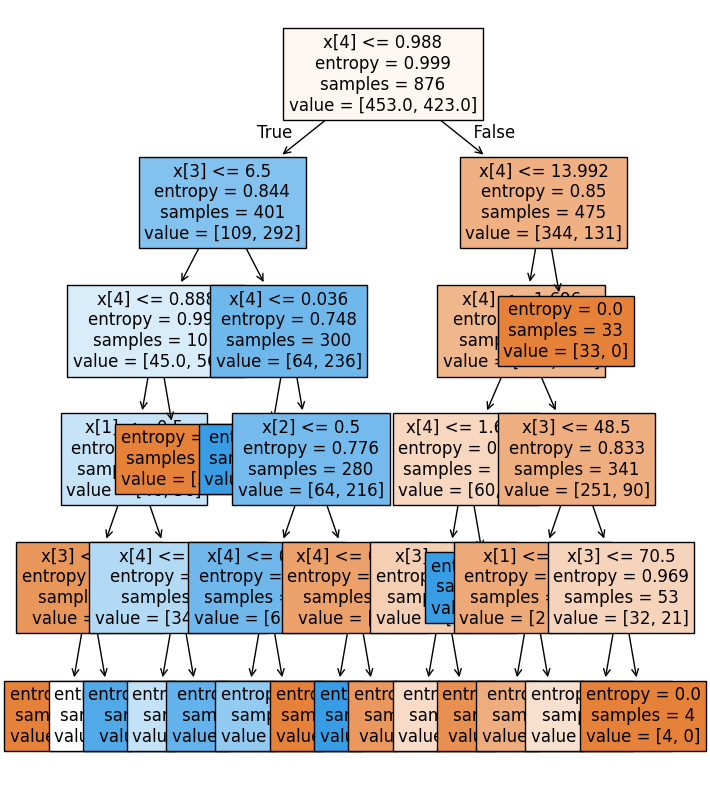

In [41]:
plt.figure(figsize=(8,10))
plot_tree(decision_tree=dt_model,fontsize=12,filled=True)
plt.show()

## 7.Model Testing

### 7.1 Training Data

In [80]:
y_pred_train = rf_classfier.predict(X_train)
y_pred_train

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

### 7.2 Test Data

In [81]:
y_pred_test  = rf_classfier.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0])

## 8.Model Evaluation

In [48]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score,roc_curve

### 8.1. Training Data's Evaluation metrics

In [95]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77       453
           1       0.76      0.71      0.74       423

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



In [83]:
print(confusion_matrix(y_train,y_pred_train))

[[360  93]
 [123 300]]


In [84]:
accuracy_score(y_train,y_pred_train)

0.7534246575342466

### ROC - Receiver operating Curve

AUC - Area under this Curve

0.7519609224554977


Text(0, 0.5, 'True Positive Rate')

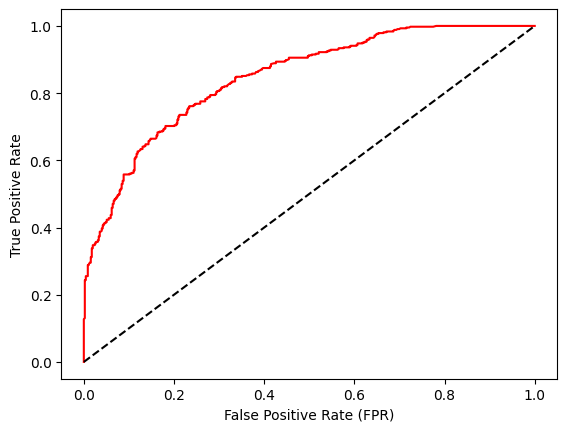

In [85]:
fpr,tpr,thresholds=roc_curve(y_train,rf_classfier.predict_proba (X_train) [:,1])
auc=roc_auc_score(y_train,y_pred_train)
print(auc)

plt.plot(fpr,tpr,color='red', label='logit model (area = %0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate")

### 8.2 Test Data's evaluation metrics

In [86]:
accuracy_score(y_test,y_pred_test)

0.7136363636363636

In [87]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.75      0.74      0.75       125
           1       0.67      0.67      0.67        95

    accuracy                           0.71       220
   macro avg       0.71      0.71      0.71       220
weighted avg       0.71      0.71      0.71       220



In [88]:
print(confusion_matrix(y_test,y_pred_test))

[[93 32]
 [31 64]]


0.7088421052631578


Text(0, 0.5, 'True Positive Rate')

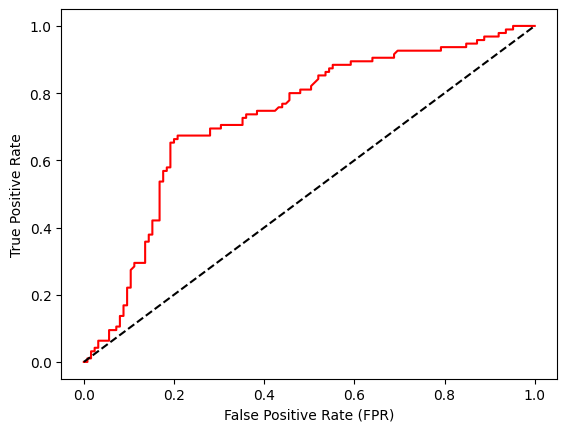

In [89]:
fpr,tpr,thresholds = roc_curve(y_test,rf_classfier.predict_proba (X_test)[:,1])
auc=roc_auc_score(y_test,y_pred_test)
print(auc)

plt.plot(fpr,tpr,color='red',label ='logit model ( area = % 0.2f)'%auc)
plt.plot([0,1],[0,1], 'k--')

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate")